In [1]:
# Install necessary libraries
!pip install -q kaggle efficientnet_pytorch mlflow

### Kaggle API Setup

This section handles the setup required to interact with the Kaggle API from Google Colab. It involves installing the Kaggle library, uploading your `kaggle.json` credentials, and configuring the permissions for secure access to Kaggle datasets.

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"randrianavalona","key":"1fb29937e15353cd993acc450074bee3"}'}

In [3]:
! mkdir ~/.kaggle

! cp kaggle.json ~/.kaggle/

In [4]:
! chmod 600 ~/.kaggle/kaggle.json

In [5]:
! kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          18076        397                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1303         36                1  
mubashirsidiki/student-academic-performance-500-students            Student Academic Performance - 500 Students               6413  2026-04-07 14:23:47.547000           5127        102

### Dataset Download and Extraction (Rice Disease)

This part of the code downloads a rice disease detection dataset from Kaggle and then extracts its contents into a local directory for further processing. This dataset is likely used for tasks related to identifying diseases in rice plants.

In [6]:
!kaggle datasets download -d hiramscud/rice-disease-detection-dataset-of-6000-images

Dataset URL: https://www.kaggle.com/datasets/hiramscud/rice-disease-detection-dataset-of-6000-images
License(s): CC-BY-SA-4.0
100% 402M/402M [00:03<00:00, 140MB/s]



In [7]:
!mkdir kaggle_data
!mkdir kaggle_data/rice_dataset
!unzip "rice-disease-detection-dataset-of-6000-images.zip" -d kaggle_data/rice_dataset

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_063_JPG_jpg.rf.71024a69335f82297f0cdf606ffb4197.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_063_JPG_jpg.rf.b5c5376c547583b9e49be885c2d61e73.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_063_JPG_jpg.rf.ccb42cc24da2a38cbc133834abfe0858.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_063_JPG_jpg.rf.e52dbc04a595bce92ba1a004bb6b4830.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_064_JPG_jpg.rf.01fc59caef0243fdcc7d62bf8747921e.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_064_JPG_jpg.rf.1ecf3125f56ee48ac53c90190113e984.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_064_JPG_jpg.rf.230152e0da382abe5719f03f995ac86d.txt  
  inflating: kaggle_data/rice_dataset/labels/train2/blast_orig_064_JPG_jpg.rf.28cd5e667984e994df36cc664

### Dataset Download and Extraction (New Plant Diseases)

Similarly, this section downloads another plant disease dataset from Kaggle, specifically a 'new plant diseases dataset'. It then extracts the downloaded ZIP file into a designated directory. This dataset will be used for training and validating a plant disease classification model.

In [8]:
# !kaggle datasets download -d nirmalsankalana/plant-diseases-training-dataset
# !mkdir kaggle_data
# !mkdir kaggle_data/plant-diseases_dataset
# !unzip "plant-diseases-training-dataset.zip" -d kaggle_data/plant-diseases_dataset

In [9]:
!rm -rf kaggle_data/new-plant-diseases_dataset

In [10]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!mkdir kaggle_data
!mkdir kaggle_data/new-plant-diseases_dataset
!unzip "new-plant-diseases-dataset.zip" -d kaggle_data/new-plant-diseases_dataset

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: kaggle_data/new-plant-diseases_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: kaggle_data/new-plant-diseases_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: kaggle_data/new-plant-diseases_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: kaggle_data/new-plant-diseases_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: kaggle_data/new-plant-diseases_dataset

### Install EfficientNet PyTorch Library

This cell installs the `efficientnet_pytorch` library, which provides pre-trained EfficientNet models for PyTorch. EfficientNet is a family of convolutional neural networks that achieve state-of-the-art accuracy with fewer parameters and FLOPs than previous models, making them suitable for image classification tasks like plant disease detection.

In [11]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=bf4a13d2781dbe5954d256f6e41bc52b4abbb17380c7d7e57d1e07602badb6ce
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


### Data Inspection and Preparation

This section verifies the structure and content of the downloaded datasets. It prints the class names available in the training and validation sets, as well as the files in the test directory. It also checks for the file extensions to ensure data consistency and removes any `.ipynb_checkpoints` directories that might interfere with data loading.

In [12]:
#!ls kaggle_data/rice_dataset/images/train

In [13]:
# !mkdir kaggle_data/new-plant-diseases_dataset/npd/npd/train/temp
# !mkdir kaggle_data/new-plant-diseases_dataset/npd/npd/test/temp

In [15]:
import os
print("Classes dans train :", os.listdir('kaggle_data/new-plant-diseases_dataset/npd/npd-train/train'))
print("Classes dans valid :", os.listdir('kaggle_data/new-plant-diseases_dataset/npd/npd-train/valid'))
print("Fichiers dans test :", os.listdir('kaggle_data/new-plant-diseases_dataset/test/test'))

Classes dans train : ['Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Potato___Early_blight', 'Peach___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Squash___Powdery_mildew', 'Pepper,_bell___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Corn_(maize)___Common_rust_', 'Apple___Black_rot', 'Tomato___Bacterial_spot', 'Corn_(maize)___healthy', 'Tomato___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Strawberry___healthy', 'Grape___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Tomato___Tomato_mosaic_virus', 'Tomato___Target_Spot', 'Raspberry___healthy', 'Blueberry___healthy', 'Apple___healthy', 'Apple___Cedar_apple_rust', 'Strawberry___Leaf_scorch', 'Peach___Bacterial_spot', 'Tomato___Leaf_Mold', 'Grape___Esca_(Black_Measles)', 'Grape___Black_rot', 'Soybean___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Corn_(maize)___Northern_Leaf_Blight', 'Apple___Apple_scab', 'Potato___healthy', 'Pepper,_bell___Bacterial_spot', 'Potato_

In [16]:
import shutil
for dir_path in [
    'kaggle_data/new-plant-diseases_dataset',
    'kaggle_data/new-plant-diseases_dataset/npd',
    'kaggle_data/new-plant-diseases_dataset/npd/npd-train/train',
    'kaggle_data/new-plant-diseases_dataset/npd/npd-train/valid',
    'kaggle_data/new-plant-diseases_dataset/test/test'
]:
    checkpoint_path = os.path.join(dir_path, '.ipynb_checkpoints')
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)

train_dir = 'kaggle_data/new-plant-diseases_dataset/npd'
test_dir_in_train = os.path.join(train_dir, 'test')
if os.path.exists(test_dir_in_train):
    shutil.rmtree(test_dir_in_train)
    print("Dossier 'test' supprimé de train.")

train_dir = 'kaggle_data/new-plant-diseases_dataset/npd/npd-train/train'
test_dir_in_train = os.path.join(train_dir, 'test')
if os.path.exists(test_dir_in_train):
    shutil.rmtree(test_dir_in_train)
    print("Dossier 'test' supprimé de train.")

In [17]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Model Training and Evaluation Pipeline

This is the core section of the notebook, implementing the training and validation pipeline for a plant disease classification model using EfficientNet. It covers:

*   **Device Configuration**: Sets up CUDA if available, otherwise uses CPU.
*   **Configuration**: Defines paths, batch size, epochs, and learning rate.
*   **Data Transforms**: Specifies image augmentations for training and basic resizing/normalization for validation.
*   **Dataset Loading**: Uses `ImageFolder` to load image datasets and `WeightedRandomSampler` to handle class imbalance during training.
*   **Model Initialization**: Loads a pre-trained EfficientNet-b0 model and replaces its final classification layer.
*   **Freezing Backbone**: Initially freezes the backbone layers and trains only the new classification head.
*   **Loss Function and Optimizer**: Uses CrossEntropyLoss with label smoothing and Adam optimizer.
*   **MLflow Integration**: Tracks training and validation metrics, best model, and confusion matrices.
*   **Fine-tuning**: Unfreezes later layers of the backbone and fine-tunes the model with a lower learning rate to improve performance.

In [18]:
import os
train_dir = 'kaggle_data/new-plant-diseases_dataset/test/test'
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        print(f"Classe {class_name} : {len(files)} fichiers")
        print(f"Exemples : {files[:3]}")

In [19]:
import os
from collections import Counter

train_dir = 'kaggle_data/new-plant-diseases_dataset/npd/npd-train/train'
valid_dir = 'kaggle_data/new-plant-diseases_dataset/npd/npd-train/valid'
test_dir = 'kaggle_data/new-plant-diseases_dataset/test/test'

def get_extensions(dir_path, name):
    extensions = []
    for root, _, files in os.walk(dir_path):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            extensions.append(ext)
    print(f"\nExtensions dans {name} :")
    print(Counter(extensions))

get_extensions(train_dir, 'train')
get_extensions(valid_dir, 'valid')
get_extensions(test_dir, 'test')


Extensions dans train :
Counter({'.jpg': 70295})

Extensions dans valid :
Counter({'.jpg': 17572})

Extensions dans test :
Counter({'.jpg': 33})


### Install MLflow

This cell installs MLflow, an open-source platform for managing the end-to-end machine learning lifecycle. It will be used to track experiments, log parameters, metrics, and models during the training process.

In [20]:
import os
import numpy as np
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from efficientnet_pytorch import EfficientNet

# ==============================
# METRICS
# ==============================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)

# ==============================
# MLflow
# ==============================
import mlflow
import mlflow.pytorch

# ==============================
# DEVICE
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# CONFIG
# ==============================
base_dir = "kaggle_data/new-plant-diseases_dataset/npd"
train_dir = os.path.join(base_dir, "npd-train/train")
valid_dir = os.path.join(base_dir, "npd-train/valid")

batch_size = 32
epochs = 15
lr = 1e-4

# ==============================
# TRANSFORMS
# ==============================
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

valid_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==============================
# DATA
# ==============================
train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
valid_ds = datasets.ImageFolder(valid_dir, transform=valid_tf)

classes = train_ds.classes
num_classes = len(classes)

# ==============================
# WEIGHTED SAMPLER
# ==============================
class_counts = np.bincount(train_ds.targets)
weights = 1.0 / class_counts
sample_weights = weights[train_ds.targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

# ==============================
# MODEL
# ==============================
model = EfficientNet.from_pretrained("efficientnet-b0")
model._fc = nn.Linear(model._fc.in_features, num_classes)
model = model.to(device)

# ==============================
# FREEZE BACKBONE (FIXED)
# ==============================
for name, param in model.named_parameters():
    if "_fc" not in name:
        param.requires_grad = False

# ==============================
# LOSS / OPTIM
# ==============================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model._fc.parameters(), lr=lr)

scaler = torch.cuda.amp.GradScaler()

# ==============================
# METRICS FUNCTIONS
# ==============================
def per_class_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)

def evaluate(y_true, y_pred):
    f1_macro = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=classes)
    return f1_macro, cm, report

# ==============================
# TRAIN LOOP (MLFLOW)
# ==============================
mlflow.set_experiment("plant_disease_research_pipeline")

best_val_loss = float("inf")

with mlflow.start_run():

    mlflow.log_param("model", "efficientnet-b0")
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("lr", lr)

    for epoch in range(epochs):

        # ================= TRAIN =================
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_preds.extend(out.argmax(1).cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        train_loss /= len(train_loader)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)

                with torch.cuda.amp.autocast():
                    out = model(x)
                    loss = criterion(out, y)

                val_loss += loss.item()
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        val_loss /= len(valid_loader)

        # ================= METRICS =================
        f1_macro, cm, report = evaluate(val_labels, val_preds)
        recalls = per_class_recall(val_labels, val_preds)

        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()

        # ================= MLFLOW LOG =================
        mlflow.log_metric("train_loss", train_loss, epoch)
        mlflow.log_metric("val_loss", val_loss, epoch)
        mlflow.log_metric("val_acc", val_acc, epoch)
        mlflow.log_metric("f1_macro", f1_macro, epoch)

        for i, r in enumerate(recalls):
            mlflow.log_metric(f"recall_class_{i}", r, epoch)

        # ================= SAVE CONFUSION MATRIX =================
        np.save(f"cm_epoch_{epoch}.npy", cm)
        mlflow.log_artifact(f"cm_epoch_{epoch}.npy")

        print(f"\nEpoch {epoch+1}")
        print(f"Loss: {train_loss:.4f} | Val: {val_loss:.4f}")
        print(f"Acc: {val_acc:.4f} | F1: {f1_macro:.4f}")

        # ================= SAVE BEST =================
        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save(model.state_dict(), "best_model.pth")
            mlflow.pytorch.log_model(model, "model")

            print("✅ Best model saved")

# ==============================
# FINE TUNING (BACKBONE UNFREEZE)
# ==============================
print("\n🔓 Fine-tuning backbone...")

for name, p in model.named_parameters():
    if "blocks.6" in name or "blocks.5" in name:
        p.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

for epoch in range(5):
    model.train()
    loss_sum = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()

    print(f"FT Epoch {epoch+1} Loss: {loss_sum/len(train_loader):.4f}")

torch.save(model.state_dict(), "final_model.pth")
mlflow.pytorch.log_model(model, "final_model")

print("🎯 FULL PIPELINE COMPLETED")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 172MB/s]


Loaded pretrained weights for efficientnet-b0


/tmp/ipykernel_2240/2494753855.py:107: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
2026/05/04 04:08:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/04 04:08:27 INFO mlflow.store.db.utils: Updating database tables
2026/05/04 04:08:29 INFO mlflow.tracking.fluent: Experiment with name 'plant_disease_research_pipeline' does not exist. Creating a new experiment.
/tmp/ipykernel_2240/2494753855.py:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2240/2494753855.py:169: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
2026/05/04 04:21:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `


Epoch 1
Loss: 2.1092 | Val: 1.3385
Acc: 0.8707 | F1: 0.8680


...

✅ Best model saved


/tmp/ipykernel_2240/2494753855.py:146: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2240/2494753855.py:169: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
2026/05/04 05:25:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 05:25:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Epoch 6
Loss: 1.0896 | Val: 1.0086
Acc: 0.9394 | F1: 0.9385


2026/05/04 05:25:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


KeyboardInterrupt: 

### Final Model Evaluation and Visualization

After the training and fine-tuning phases, this section loads the best-performing model (based on validation loss) and performs a comprehensive evaluation on the validation set. It generates and displays:

*   **Classification Report**: Provides precision, recall, F1-score, and support for each class, giving a detailed breakdown of model performance.
*   **Confusion Matrix**: Visualizes the performance of the classification model, showing the number of correct and incorrect predictions for each class. This helps identify specific classes where the model might be struggling.


📊 Evaluation du meilleur modèle...

📌 Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9571    0.9306    0.9437       504
                                 Apple___Black_rot     0.9778    0.9759    0.9768       497
                          Apple___Cedar_apple_rust     0.9761    0.9273    0.9510       440
                                   Apple___healthy     0.9702    0.9721    0.9711       502
                               Blueberry___healthy     0.9715    0.9758    0.9736       454
          Cherry_(including_sour)___Powdery_mildew     0.9517    0.9834    0.9673       421
                 Cherry_(including_sour)___healthy     0.9784    0.9934    0.9859       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9576    0.8268    0.8874       410
                       Corn_(maize)___Common_rust_     1.0000    0.9937    0.9968       477
               Co

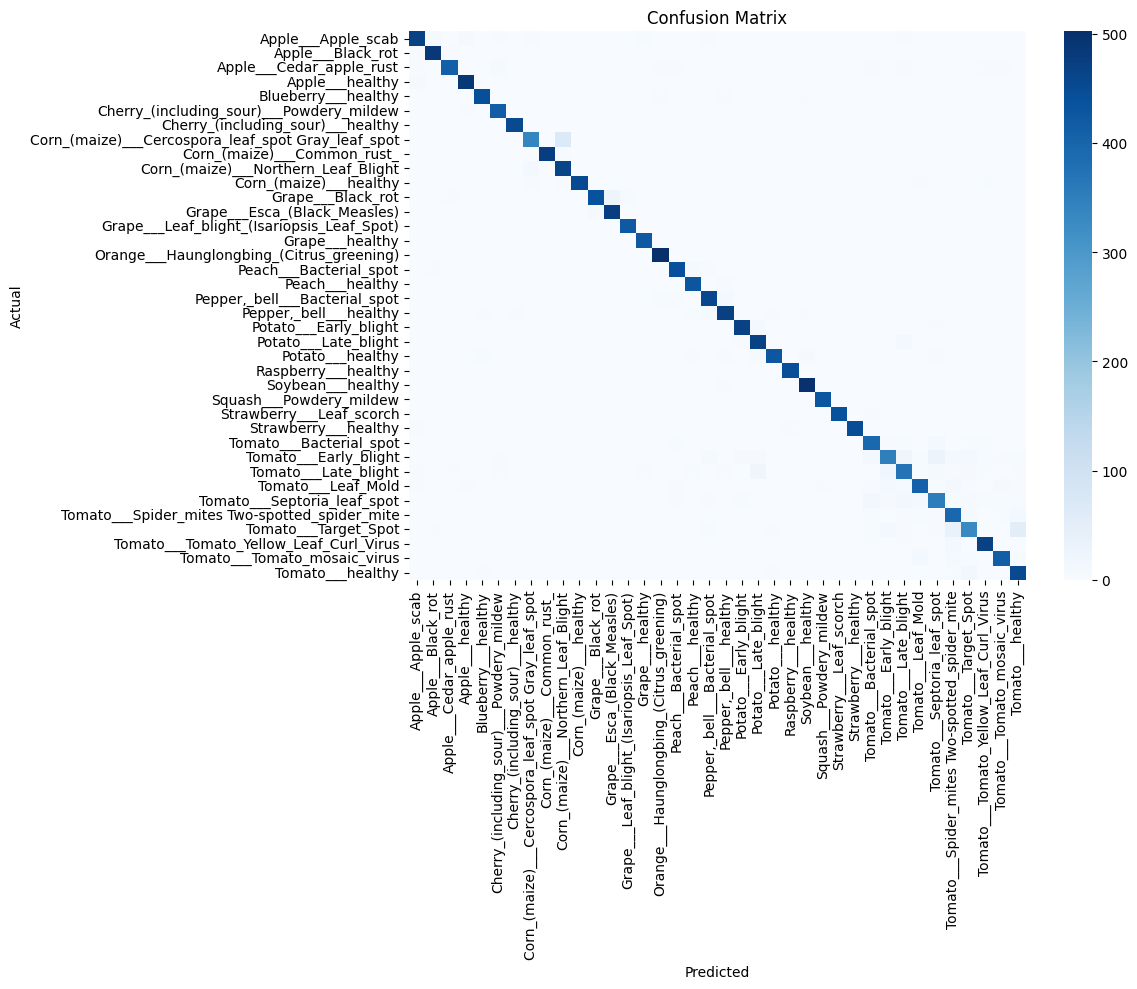

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, dataloader, class_names):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = confusion_matrix(all_labels, all_preds)

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )

    return cm, report

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


print("\n📊 Evaluation du meilleur modèle...")

# Charger le meilleur modèle
model.load_state_dict(torch.load("best_model.pth"))

cm, report = evaluate_model(model, valid_loader, train_ds.classes)

print("\n📌 Classification Report:")
print(report)

print("\n📌 Confusion Matrix:")
print(cm)

plot_confusion_matrix(cm, train_ds.classes)